<a href="https://colab.research.google.com/github/aha2003/brain-tumor-classfication-FYP2025/blob/main/EfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import os
from google.colab import drive

drive.mount('/content/drive')

base_path = '/content/drive/My Drive/Kaggle_Datasets/mri-brain-tumor-dataset'
train_dir = os.path.join(base_path, 'Training')
test_dir = os.path.join(base_path, 'Testing')

IMG_SIZE = (224, 224)
BATCH_SIZE = 16


val_split_pct = 450 / 2935

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=val_split_pct, subset="training",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=val_split_pct, subset="validation",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

Mounted at /content/drive
Found 2870 files belonging to 4 classes.
Using 2430 files for training.
Found 2870 files belonging to 4 classes.
Using 440 files for validation.
Found 394 files belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

def prepare_effnet_ds(ds):

    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(buffer_size=AUTOTUNE)

train_ds_eff = prepare_effnet_ds(train_ds)
val_ds_eff = prepare_effnet_ds(val_ds)
test_ds_eff = prepare_effnet_ds(test_ds)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models


base_model_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


base_model_eff.trainable = False


model_eff = models.Sequential([
    base_model_eff,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])


model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_eff.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint_path_eff = os.path.join(base_path, 'effnet_phase1_best.keras')
checkpoint_eff = ModelCheckpoint(checkpoint_path_eff, monitor='val_accuracy', save_best_only=True)

print("Starting EfficientNet-B0 Phase 1: Feature Extraction...")
history_eff = model_eff.fit(
    train_ds_eff,
    validation_data=val_ds_eff,
    epochs=10,
    callbacks=[early_stop, checkpoint_eff]
)

Starting EfficientNet-B0 Phase 1: Feature Extraction...
Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.5206 - loss: 1.1050 - val_accuracy: 0.7250 - val_loss: 0.8055
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.7025 - loss: 0.7887 - val_accuracy: 0.7886 - val_loss: 0.6267
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.7556 - loss: 0.6427 - val_accuracy: 0.8068 - val_loss: 0.5405
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.7881 - loss: 0.5745 - val_accuracy: 0.8182 - val_loss: 0.4861
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.8066 - loss: 0.5307 - val_accuracy: 0.8182 - val_loss: 0.4535
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.8177 - loss: 0.5067 - val_accuracy: 0.8295 - val_loss: 0.4281
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.8329 - loss: 0.4607 - val_accuracy: 0.8568 - val_loss: 0.4003
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os


model_path = os.path.join(base_path, 'effnet_phase1_best.keras')
model_eff = tf.keras.models.load_model(model_path)


base_model_eff = model_eff.layers[0]
base_model_eff.trainable = True


for layer in base_model_eff.layers[:-20]:
    layer.trainable = False


model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


checkpoint_path_eff_p2 = os.path.join(base_path, 'effnet_final_fine_tuned.keras')
checkpoint_eff_p2 = ModelCheckpoint(checkpoint_path_eff_p2, monitor='val_accuracy', save_best_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Starting EfficientNet-B0 Phase 2: Fine-Tuning...")
history_eff_p2 = model_eff.fit(
    train_ds_eff,
    validation_data=val_ds_eff,
    epochs=10,
    callbacks=[early_stop, checkpoint_eff_p2]
)

Starting EfficientNet-B0 Phase 2: Fine-Tuning...
Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.7115 - loss: 0.7941 - val_accuracy: 0.8205 - val_loss: 0.4680
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.7860 - loss: 0.6207 - val_accuracy: 0.8182 - val_loss: 0.4785
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.8008 - loss: 0.5625 - val_accuracy: 0.8364 - val_loss: 0.4505
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.8267 - loss: 0.5100 - val_accuracy: 0.8477 - val_loss: 0.4244
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.8309 - loss: 0.4706 - val_accuracy: 0.8523 - val_loss: 0.3986
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - accuracy: 0.8486 - loss: 0.4475 - val_accuracy: 0.8591 - val_loss: 0.3784
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.8564 - loss: 0.4102 - val_accuracy: 0.8659 - val_loss: 0.3594
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/

Running inference on test dataset for EfficientNet-B0...

--- EfficientNet-B0 Classification Report ---
                  precision    recall  f1-score   support

    glioma_tumor       0.76      0.22      0.34       100
meningioma_tumor       0.61      0.73      0.67       115
        no_tumor       0.60      0.90      0.72       105
 pituitary_tumor       0.83      0.81      0.82        74

        accuracy                           0.66       394
       macro avg       0.70      0.66      0.64       394
    weighted avg       0.69      0.66      0.63       394



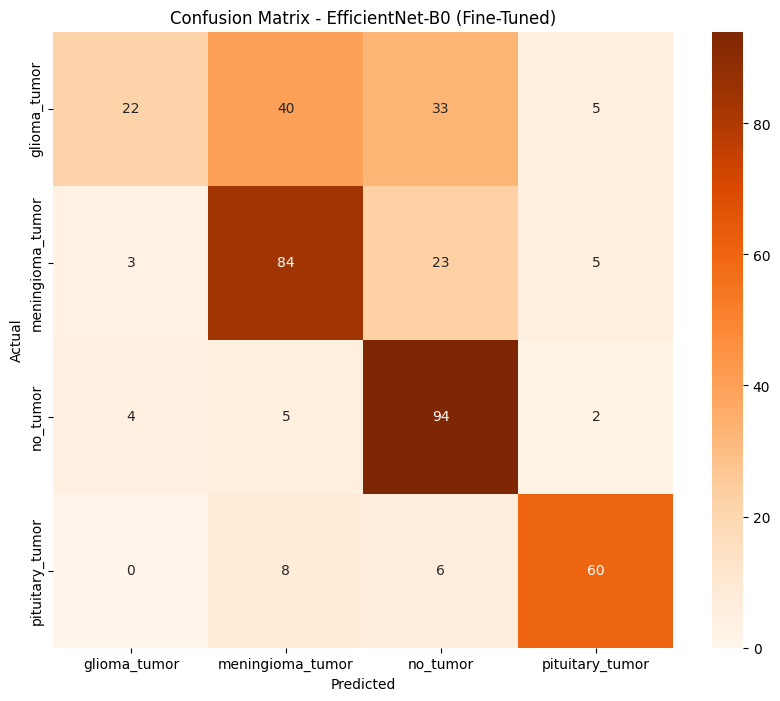

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os
import tensorflow as tf


model_path = os.path.join(base_path, 'effnet_final_fine_tuned.keras')
final_eff_model = tf.keras.models.load_model(model_path)


class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


test_labels = []
test_preds = []

print("Running inference on test dataset for EfficientNet-B0...")
for images, labels in test_ds_eff:
    preds = final_eff_model.predict(images, verbose=0)
    test_labels.extend(np.argmax(labels, axis=1))
    test_preds.extend(np.argmax(preds, axis=1))


print("\n--- EfficientNet-B0 Classification Report ---")
print(classification_report(test_labels, test_preds, target_names=class_names))


cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - EfficientNet-B0 (Fine-Tuned)')
plt.show()

In [ ]:
import tensorflow as tf
import os


model_path = os.path.join(base_path, 'effnet_final_fine_tuned.keras')


model_eff = tf.keras.models.load_model(model_path)

print("EfficientNet-B0 successfully reloaded.")

EfficientNet-B0 successfully reloaded.


Generating predictions for EfficientNet-B0...
✓ Saved: effnet_report.csv


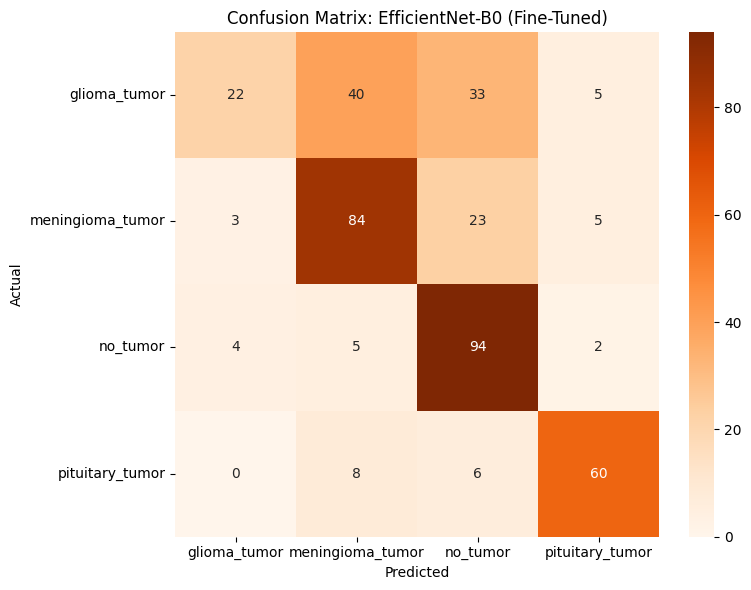

✓ Saved: effnet_cm.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix


class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

def save_effnet_assets(model, test_dataset, save_path):
    print("Generating predictions for EfficientNet-B0...")

    test_labels = []
    test_preds = []


    for images, labels in test_dataset:
        preds = model.predict(images, verbose=0)
        test_labels.extend(np.argmax(labels, axis=1))
        test_preds.extend(np.argmax(preds, axis=1))


    report = classification_report(test_labels, test_preds,
                                   target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(save_path, 'effnet_report.csv'))
    print("✓ Saved: effnet_report.csv")


    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(test_labels, test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix: EfficientNet-B0 (Fine-Tuned)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()

    plt.savefig(os.path.join(save_path, 'effnet_cm.png'), dpi=300)
    plt.show()
    print("✓ Saved: effnet_cm.png")

# Execute
save_effnet_assets(model_eff, test_ds_eff, base_path)

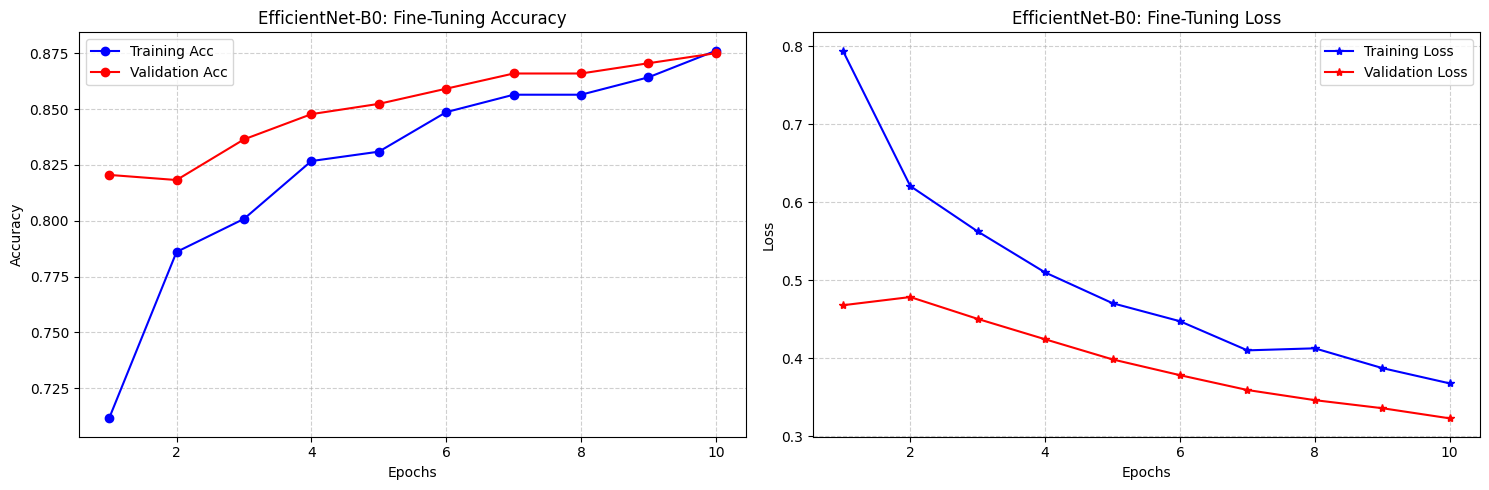

✓ Saved: effnet_learning_curves_final.png to Drive.


In [ ]:
import matplotlib.pyplot as plt
import os


epochs = range(1, 11)
acc = [0.7115, 0.7860, 0.8008, 0.8267, 0.8309, 0.8486, 0.8564, 0.8564, 0.8642, 0.8761]
val_acc = [0.8205, 0.8182, 0.8364, 0.8477, 0.8523, 0.8591, 0.8659, 0.8659, 0.8705, 0.8750]
loss = [0.7941, 0.6207, 0.5625, 0.5100, 0.4706, 0.4475, 0.4102, 0.4128, 0.3875, 0.3679]
val_loss = [0.4680, 0.4785, 0.4505, 0.4244, 0.3986, 0.3784, 0.3594, 0.3464, 0.3361, 0.3231]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))


ax1.plot(epochs, acc, 'bo-', label='Training Acc')
ax1.plot(epochs, val_acc, 'ro-', label='Validation Acc')
ax1.set_title('EfficientNet-B0: Fine-Tuning Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)


ax2.plot(epochs, loss, 'b*-', label='Training Loss')
ax2.plot(epochs, val_loss, 'r*-', label='Validation Loss')
ax2.set_title('EfficientNet-B0: Fine-Tuning Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'effnet_learning_curves_final.png'), dpi=300)
plt.show()

print("✓ Saved: effnet_learning_curves_final.png to Drive.")

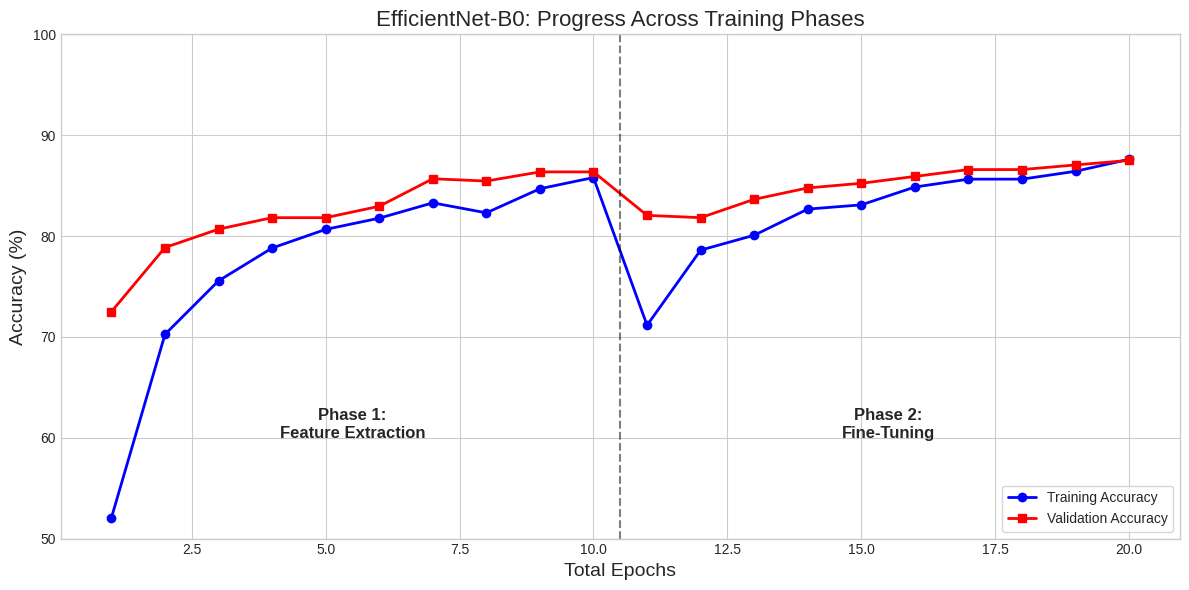

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os


effnet_train_acc = [0.5206, 0.7025, 0.7556, 0.7881, 0.8066, 0.8177, 0.8329, 0.8230, 0.8469, 0.8580] + \
                   [0.7115, 0.7860, 0.8008, 0.8267, 0.8309, 0.8486, 0.8564, 0.8564, 0.8642, 0.8761]

effnet_val_acc = [0.7250, 0.7886, 0.8068, 0.8182, 0.8182, 0.8295, 0.8568, 0.8545, 0.8636, 0.8636] + \
                 [0.8205, 0.8182, 0.8364, 0.8477, 0.8523, 0.8591, 0.8659, 0.8659, 0.8705, 0.8750]

total_epochs = np.arange(1, 21)


plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(total_epochs, [x * 100 for x in effnet_train_acc], 'b-o', label='Training Accuracy', linewidth=2)
plt.plot(total_epochs, [x * 100 for x in effnet_val_acc], 'r-s', label='Validation Accuracy', linewidth=2)

plt.axvline(x=10.5, color='black', linestyle='--', alpha=0.5)
plt.text(5.5, 60, 'Phase 1:\nFeature Extraction', fontsize=12, ha='center', fontweight='bold')
plt.text(15.5, 60, 'Phase 2:\nFine-Tuning', fontsize=12, ha='center', fontweight='bold')

plt.title('EfficientNet-B0: Progress Across Training Phases', fontsize=16)
plt.xlabel('Total Epochs', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.ylim(50, 100)
plt.legend(loc='lower right', frameon=True, facecolor='white')

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'effnet_full_lifecycle.png'), dpi=300)
plt.show()